# BUSINFO701 Group 2 Project Report

Google Drive: https://drive.google.com/drive/folders/1N9bbPRY1_RzPMOAe8tKCl8OkkBELUhqQ?usp=drive_link

# Part 1: Data Wrangling and Combining

## Data Sourcing
1. Country Statistics - UNData: https://www.kaggle.com/datasets/sudalairajkumar/undata-country-profiles
2. Global Health Workforce Statistics - WHO, including medical doctor density data and nursing & midwifery density data: https://www.who.int/data/gho/data/themes/topics/health-workforce
3. World University Rankings: https://www.kaggle.com/datasets/mylesoneill/world-university-rankings
4. Worldometer - Real Time World Satatistics, for web scraping: https://www.worldometers.info/#google_vignette

In [2]:
# Import data

import pandas as pd

# UNCountries data 
raw = pd.read_csv("Country Statistics - UNData - 2017.csv")

# Medical Doctor Density data
raw_md = pd.read_csv("WHO-Healthcare Workforce-Medical doctors.csv")

# Nursing and midwifery Density data
raw_nurse = pd.read_csv("WHO-Healthcare Workfore-Nursing and midwife.csv")

# Education data
raw_Education = pd.read_csv("timesData.csv")

## Data Cleaning

### 1. Country Statistics - UNData - 2017
This dataset contains statistical information for 229 entries (countries or regions) with 50 columns describing various socio-economic, demographic, and development indicators. Relevant columns was selected to focus on key demographic, economic, health, and education indicators. These columns were then renamed to enhance clarity, making them more intuitive for further use. A custom function was applied to "Tertiary education enrollment rate" column, calculating the averages or returning None for invalid entries.The column containing life expectancy data for females and males was split into two separate columns, with the original being dropped afterward. Invalid or null-like values, such as placeholders and anomalies, were replaced with zeroes to maintain consistency. Certain columns, particularly those containing numerical data like infant mortality rates and education expenditures, were converted to float data types to facilitate numerical operations. Rows with zeroes were removed to improve dataset quality. 

In [3]:
#Inspect dataset structure and characteristics
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229 entries, 0 to 228
Data columns (total 50 columns):
 #   Column                                                      Non-Null Count  Dtype  
---  ------                                                      --------------  -----  
 0   country                                                     229 non-null    object 
 1   Region                                                      229 non-null    object 
 2   Surface area (km2)                                          229 non-null    object 
 3   Population in thousands (2017)                              229 non-null    int64  
 4   Population density (per km2, 2017)                          229 non-null    float64
 5   Sex ratio (m per 100 f, 2017)                               229 non-null    float64
 6   GDP: Gross domestic product (million current US$)           229 non-null    int64  
 7   GDP growth rate (annual %, const. 2005 prices)              229 non-null    object 
 8   

In [4]:
# Select and rename columns of interest
country_stat_2017 = raw[["country","Region",
                         "Population density (per km2, 2017)","Urban population (% of total population)",
                         "GDP per capita (current US$)",
                         "Life expectancy at birth (females/males, years)","Infant mortality rate (per 1000 live births",
                         "Health: Total expenditure (% of GDP)","Education: Government expenditure (% of GDP)",
                         "Education: Tertiary gross enrol. ratio (f/m per 100 pop.)",
                         "Unemployment (% of labour force)"]]

country_stat_2017 = country_stat_2017.rename(columns={"country":"Country",
                                                      "Population density (per km2, 2017)":"Population density",
                                                      "Urban population (% of total population)":"Urban population",
                                                      "GDP growth rate (annual %, const. 2005 prices)":"GDP growth rate",
                                                      "GDP per capita (current US$)":"GDP per capita",
                                                      "Infant mortality rate (per 1000 live births":"Infant mortality rate",
                                                      "Health: Total expenditure (% of GDP)":"Health expenditure",
                                                      "Health: Physicians (per 1000 pop.)":"Physicians density",
                                                      "Education: Government expenditure (% of GDP)":"Education government expenditure",
                                                      "Education: Tertiary gross enrol. ratio (f/m per 100 pop.)": "Tertiary education enrollment rate"})
#Inspect extracted dataset
country_stat_2017.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229 entries, 0 to 228
Data columns (total 11 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Country                                          229 non-null    object 
 1   Region                                           229 non-null    object 
 2   Population density                               229 non-null    float64
 3   Urban population                                 229 non-null    float64
 4   GDP per capita                                   229 non-null    float64
 5   Life expectancy at birth (females/males, years)  229 non-null    object 
 6   Infant mortality rate                            229 non-null    object 
 7   Health expenditure                               229 non-null    float64
 8   Education government expenditure                 229 non-null    object 
 9   Tertiary education enrollment ra

In [5]:
# Function to calculate the average of a value with "/" or handle invalid values
def average(value):
    # If the value contains "..." or is "-99", it is considered invalid, and None is returned
    if "..." in value or value == "-99":
        return None
    # If the value contains "/", it splits it into two parts, converts them to float, and calculates their mean
    elif "/" in value:
        p1 = value.split("/")
        mean = (float(p1[0]) + float(p1[1])) / 2
        return float(mean)

# Apply the average function to the "Tertiary education enrollment rate" column
country_stat_2017["Tertiary education enrollment rate"] = country_stat_2017["Tertiary education enrollment rate"].apply(average)

# Split the "Life expectancy at birth (females/males, years)" column into two separate columns: Female and Male life expectancy
country_stat_2017[["Female life expectancy", "Male life expectancy"]] = country_stat_2017["Life expectancy at birth (females/males, years)"].str.split("/", expand=True)

# Drop the original "Life expectancy at birth (females/males, years)" column as it has been split
country_stat_2017.drop(columns="Life expectancy at birth (females/males, years)", inplace=True)

# Remove invalid or null-like values in the dataset and replace them with 0 for cleaning
null_values = ["...", "-~0.0", "~0.0", ".../..."]
country_stat_2017.replace(null_values, 0, inplace=True)

# Convert specific columns to float type for proper numerical analysis
convert_columns = ["Infant mortality rate", "Education government expenditure", "Female life expectancy", "Male life expectancy"]
country_stat_2017[convert_columns] = country_stat_2017[convert_columns].astype(float)

# Replace anomalous values (-99 or -99.0) with 0
null_values = [-99, -99.0]
country_stat_2017.replace(null_values, 0, inplace=True)

# Filter out rows where any column has a value of 0 to exclude invalid data
country_stat_2017 = country_stat_2017[(country_stat_2017 != 0).all(axis=1)]

# Display information about the cleaned dataset, such as column types and non-null counts
country_stat_2017.info()

# Reset the index of the cleaned dataset to maintain a consistent row index
country_stat_2017.reset_index(drop=True, inplace=True)

<class 'pandas.core.frame.DataFrame'>
Index: 134 entries, 0 to 228
Data columns (total 12 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Country                             134 non-null    object 
 1   Region                              134 non-null    object 
 2   Population density                  134 non-null    float64
 3   Urban population                    134 non-null    float64
 4   GDP per capita                      134 non-null    float64
 5   Infant mortality rate               134 non-null    float64
 6   Health expenditure                  134 non-null    float64
 7   Education government expenditure    134 non-null    float64
 8   Tertiary education enrollment rate  119 non-null    float64
 9   Unemployment (% of labour force)    134 non-null    object 
 10  Female life expectancy              134 non-null    float64
 11  Male life expectancy                134 non-null  

In [6]:
# Inspect numeric columns
country_stat_2017.describe()

,Population density,Urban population,GDP per capita,Infant mortality rate,Health expenditure,Education government expenditure,Tertiary education enrollment rate,Female life expectancy,Male life expectancy
count,134.000000,134.000000,134.000000,134.000000,134.000000,134.000000,119.000000,134.000000,134.000000
mean,228.773134,58.050746,14221.370149,25.329851,6.909701,4.714925,40.793697,74.014179,69.047015
std,743.432521,23.080320,19313.563139,24.442475,2.738142,1.714358,28.799109,8.753252,7.967988
min,2.000000,12.100000,244.600000,1.600000,1.500000,1.200000,0.800000,50.700000,47.800000
25%,35.600000,39.025000,1385.125000,4.825000,4.900000,3.500000,13.400000,67.900000,63.925000
50%,86.350000,59.650000,5761.900000,14.700000,6.750000,4.750000,38.850000,77.100000,70.500000
75%,200.725000,76.625000,15955.325000,42.500000,8.775000,5.500000,65.350000,80.800000,75.550000
max,8155.500000,100.000000,100160.800000,94.400000,17.100000,12.500000,94.650000,86.400000,80.600000


### 2. WHO Medical Doctors

This dataset contains 12,775 rows and 34 columns, capturing a mix of indicator-based statistics across various locations and time periods. Key columns include Indicator, Value, ParentLocation, Location, and Period. Relevant columns were selected, while filtering rows where the indicator specifies "Medical doctors (per 10,000)". Renames columns for clarity (e.g., "ParentLocation" to "Region," "Location" to "Country," "Period" to "Year," and "Value" to "Medical doctors density"). The "Indicator" column is dropped as it is no longer needed, and the "Medical doctors density" column is converted to a float data type for numerical operations. Finally, the dataset is filtered to retain only records from the year 2017, creating a refined dataset for analysis.

In [7]:
raw_md.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12775 entries, 0 to 12774
Data columns (total 34 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   IndicatorCode               12775 non-null  object 
 1   Indicator                   12775 non-null  object 
 2   ValueType                   12775 non-null  object 
 3   ParentLocationCode          12775 non-null  object 
 4   ParentLocation              12775 non-null  object 
 5   Location type               12775 non-null  object 
 6   SpatialDimValueCode         12775 non-null  object 
 7   Location                    12775 non-null  object 
 8   Period type                 12775 non-null  object 
 9   Period                      12775 non-null  int64  
 10  IsLatestYear                12775 non-null  bool   
 11  Dim1 type                   0 non-null      float64
 12  Dim1                        0 non-null      float64
 13  Dim1ValueCode               0 n

In [8]:
# Select columns of interest: Indicator, ParentLocation, Location, Period, and Value
who_md = raw_md[["Indicator", "ParentLocation", "Location", "Period", "Value"]]

# Filter rows where the "Indicator" column equals "Medical doctors (per 10,000)"
# This ensures that the dataset only contains information about the density of medical doctors
who_md = who_md.loc[who_md["Indicator"] == "Medical doctors (per 10,000)"]

# Rename columns for clarity and consistency
# - "ParentLocation" renamed to "Region" to indicate geographic regions
# - "Location" renamed to "Country" to clearly identify countries
# - "Period" renamed to "Year" to denote the time period
# - "Value" renamed to "Medical doctors density" for descriptive clarity
who_md.rename(columns={
    "ParentLocation": "Region",
    "Location": "Country",
    "Period": "Year",
    "Value": "Medical doctors density"
}, inplace=True)

# Drop the "Indicator" column as it is no longer needed (all rows now represent the same indicator)
who_md.drop(columns="Indicator", inplace=True)

# Inspect cleaned dataset
who_md


,Region,Country,Year,Medical doctors density
0,Africa,Guinea,2022,0.214
1,Africa,Niger,2022,0.234
2,Africa,Sierra Leone,2022,0.425
3,Africa,Malawi,2022,0.488
4,Africa,Eritrea,2022,0.706
...,...,...,...,...
11221,Eastern Mediterranean,Oman,1990,7.986
11222,Americas,Colombia,1990,8.028
11223,Western Pacific,Republic of Korea,1990,8.11
11224,Europe,Türkiye,1990,9.322


In [9]:
# Convert the "Medical doctors density" column to a float data type
who_md["Medical doctors density"] = who_md["Medical doctors density"].astype(float)

# Filter the dataset to include only rows where the "Year" column equals 2017
who_md_2017 = who_md.loc[who_md["Year"] == 2017]

### 3. Nursing and midwifery personnel

This dataset contains 12,341 rows and 34 columns, capturing a mix of indicator-based statistics across various locations and time periods. Relevant columns were selected, while filtering rows where the indicator specifies "Nursing and midwifery personnel (per 10,000)". Renames columns for clarity (e.g., "ParentLocation" to "Region," "Location" to "Country," "Period" to "Year," and "Value" to "Nursing and midwifery density"). The "Indicator" column is dropped as it is no longer needed, and the "Medical doctors density" column is converted to a float data type for numerical operations. Finally, the dataset is filtered to retain only records from the year 2017, creating a refined dataset for analysis.

In [10]:
raw_nurse.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12341 entries, 0 to 12340
Data columns (total 34 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   IndicatorCode               12341 non-null  object 
 1   Indicator                   12341 non-null  object 
 2   ValueType                   12341 non-null  object 
 3   ParentLocationCode          12341 non-null  object 
 4   ParentLocation              12341 non-null  object 
 5   Location type               12341 non-null  object 
 6   SpatialDimValueCode         12341 non-null  object 
 7   Location                    12341 non-null  object 
 8   Period type                 12341 non-null  object 
 9   Period                      12341 non-null  int64  
 10  IsLatestYear                12341 non-null  bool   
 11  Dim1 type                   0 non-null      float64
 12  Dim1                        0 non-null      float64
 13  Dim1ValueCode               0 n

In [11]:
# Select columns of interest
who_nurse = raw_nurse[["Indicator", "ParentLocation", "Location", "Period", "Value"]]

# Filter rows where the "Indicator" column equals "Nursing and midwifery personnel (per 10,000)"
# This ensures the dataset contains only information about the density of nursing and midwifery personnel
who_nurse = who_nurse.loc[who_nurse["Indicator"] == "Nursing and midwifery personnel (per 10,000)"]

# Rename columns for clarity and consistency
# - "ParentLocation" renamed to "Region" to indicate geographic regions
# - "Location" renamed to "Country" to clearly identify countries
# - "Period" renamed to "Year" to denote the time period
# - "Value" renamed to "Nursing and midwifery density" for descriptive clarity
who_nurse.rename(columns={
    "ParentLocation": "Region",
    "Location": "Country",
    "Period": "Year",
    "Value": "Nursing and midwifery density"
}, inplace=True)

# Drop the "Indicator" column as it is no longer needed (all rows now represent the same indicator)
who_nurse.drop(columns="Indicator", inplace=True)

# Inspect cleaned dataset
who_nurse

,Region,Country,Year,Nursing and midwifery density
0,Africa,Burkina Faso,2022,10.256
1,Africa,Congo,2022,10.854
2,Americas,Canada,2022,103.104
3,Africa,Sierra Leone,2022,11.187
4,Africa,Democratic Republic of the Congo,2022,11.914
...,...,...,...,...
11427,Americas,Costa Rica,1990,8.606
11428,Europe,Estonia,1990,87.923
11429,Americas,Brazil,1990,9.388
11430,Western Pacific,New Zealand,1990,91.997


In [12]:
# Convert the "Nursing and midwifery density" column to a float data type
who_nurse["Nursing and midwifery density"] = who_nurse["Nursing and midwifery density"].astype(float)

# Filter the dataset to include only rows where the "Year" column equals 2017
who_nurse_2017 = who_nurse.loc[who_nurse["Year"] == 2017]

### Merge the `who_nurse_2017`, `who_md_2017` and `country_stat_2017` DataFrames

In [13]:
# Merge the `who_nurse_2017` and `who_md_2017` DataFrames
# - Join is performed on the common columns "Region" and "Country" to align data for the same countries and regions
# - "how='left'" ensures all rows from `who_nurse_2017` are retained, and matching rows from `who_md_2017` are included
#   (if no match is found, the missing values will be filled with NaN)
who_2017 = pd.merge(who_nurse_2017, who_md_2017, how="left", on=["Region", "Country"])

# Inspect the merged dataframe
who_2017.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 6 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Region                         146 non-null    object 
 1   Country                        146 non-null    object 
 2   Year_x                         146 non-null    int64  
 3   Nursing and midwifery density  146 non-null    float64
 4   Year_y                         115 non-null    float64
 5   Medical doctors density        115 non-null    float64
dtypes: float64(3), int64(1), object(2)
memory usage: 7.0+ KB


In [14]:
# Merge the `who_2017` and `country_stat_2017` DataFrames
# - The merge is performed on the "Country" column to combine health-related data with country statistics
# - "how='left'" ensures all rows from `who_2017` are retained, even if there is no matching data in `country_stat_2017`
health_2017 = pd.merge(who_2017, country_stat_2017, how="left", on="Country")

# Display information about the merged DataFrame
# Inspect the merged dataframe
health_2017.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 17 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Region_x                            146 non-null    object 
 1   Country                             146 non-null    object 
 2   Year_x                              146 non-null    int64  
 3   Nursing and midwifery density       146 non-null    float64
 4   Year_y                              115 non-null    float64
 5   Medical doctors density             115 non-null    float64
 6   Region_y                            105 non-null    object 
 7   Population density                  105 non-null    float64
 8   Urban population                    105 non-null    float64
 9   GDP per capita                      105 non-null    float64
 10  Infant mortality rate               105 non-null    float64
 11  Health expenditure                  105 non-n

In [15]:
# Drop the "Region_y" column from the `health_2017` DataFrame
# Keeping only the relevant column ensures the dataframe is cleaner and avoids redundancy
health_2017.drop(columns="Region_y", inplace=True)

In [16]:
# Check for missing values in the `health_2017` DataFrame
health_2017.isna().sum()

Region_x                               0
Country                                0
Year_x                                 0
Nursing and midwifery density          0
Year_y                                31
Medical doctors density               31
Population density                    41
Urban population                      41
GDP per capita                        41
Infant mortality rate                 41
Health expenditure                    41
Education government expenditure      41
Tertiary education enrollment rate    51
Unemployment (% of labour force)      41
Female life expectancy                41
Male life expectancy                  41
dtype: int64

### 4. Education Information

This dataset contains 14 columns and 2603 rows with The Times Higher Education World University Ranking from top in the world to the 800th in the world. Country, year, and the number of students is extracted to analyse the count of both universities and students within these universities globally. The dataset was grouped by country to count the unique occurrences of universities, creating a new column called Count Of Universities.

To explore student demographics, the num_students column is cleaned by defining a function to handle inconsistencies in formatting, such as commas and non-numeric entries. Invalid values were replaced with zero, and the column was converted to integers. The dataset was then grouped by country to calculate the median number of students per country, renaming the result to Average Number Of Students for clarity. Finally, the university counts and student numbers were merged into a single dataset, combining the count of universities with the average number of students by country.

In [17]:
# Create a dictionary `rename_map` to map country names to their simplified or standard versions
rename_map = {
    "Czechia": "Czech Republic", 
    "Netherlands (Kingdom of the)": "Netherlands",  
    "Iran (Islamic Republic of)": "Iran", 
    "Türkiye": "Turkey",  
    "Republic of Korea": "South Korea",  
    "China, Macao Special Administrative Region": "Macau",  
    "China, Hong Kong Special Administrative Region": "Hong Kong",  
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom"  
}

# Apply the renaming to the "Country" column in the `health_2017` dataframe
health_2017["Country"] = health_2017["Country"].replace(rename_map)


In [18]:
raw_Education.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2603 entries, 0 to 2602
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   world_rank              2603 non-null   object 
 1   university_name         2603 non-null   object 
 2   country                 2603 non-null   object 
 3   teaching                2603 non-null   float64
 4   international           2603 non-null   object 
 5   research                2603 non-null   float64
 6   citations               2603 non-null   float64
 7   income                  2603 non-null   object 
 8   total_score             2603 non-null   object 
 9   num_students            2544 non-null   object 
 10  student_staff_ratio     2544 non-null   float64
 11  international_students  2536 non-null   object 
 12  female_male_ratio       2370 non-null   object 
 13  year                    2603 non-null   int64  
dtypes: float64(4), int64(1), object(9)
memor

In [102]:
# Extract relevant columns from the raw Education dataset for further analysis
EducationYear = raw_Education.loc[:, ['country', 'year', 'university_name']]

# Count the unique universities per country
# - Group by 'country' and count the unique occurrences of 'university_name'
# - Reset the index to create a new dataframe with the counts
UniCount = EducationYear.groupby('country')['university_name'].nunique().reset_index(name='Count Of Universities')

# Extract relevant columns from the raw Education dataset for student numbers
Education = raw_Education.loc[:, ['country', 'num_students']]

# Define a function to clean and convert the 'num_students' values
# - Handles cases where numbers are formatted with commas or non-numeric entries
# - Replaces commas, checks if the value is a digit, and converts to an integer
# - If not a digit, returns 0 to handle invalid or missing values
def NumberStudents(value):
    value = str(value)  
    if "," in value:
        value = value.replace(",", "")  
    return int(value) if value.isdigit() else 0 

# Apply the `NumberStudents` function to the 'num_students' column to clean and standardize the data
Education['num_students'] = Education['num_students'].apply(NumberStudents)

# Group by 'country' and calculate the median number of students per country
# - Aggregates the 'num_students' column to find the median value
# - Resets the index to create a new DataFrame with the results
EducationGrouped = Education.groupby('country').agg(
    avg_num_students=('num_students', 'median'),  # Calculate the median for 'num_students'
).reset_index()

# Rename the aggregated column to make its purpose clear
EducationGrouped.rename(columns={
    'avg_num_students': 'Average Number Of Students',
}, inplace=True)

# Merge the university counts with the median student numbers by country
# - Perform an inner join on the 'country' column to combine the two datasets
EducationGrouped = pd.merge(UniCount, EducationGrouped, how='inner', left_on='country', right_on='country')
EducationGrouped

,country,Count Of Universities,Average Number Of Students
0,Argentina,1,108373.0
1,Australia,31,23508.0
2,Austria,7,20584.0
3,Bangladesh,1,62716.0
4,Belarus,1,29303.0
...,...,...,...
67,Unisted States of America,1,0.0
68,United Arab Emirates,2,7223.5
69,United Kingdom,78,15489.0
70,United States of America,161,21379.0


In [20]:
# Merge the `health_2017` DataFrame with `EducationGrouped`
# - Combines health-related data with education data (university counts and student numbers)
# - The merge is performed on the 'Country' column from `health_2017` and 'country' column from `EducationGrouped`
# - A left join ensures all rows from `health_2017` are retained, and matching rows from `EducationGrouped` are added
health_2017_final = pd.merge(health_2017, EducationGrouped, how='left', left_on='Country', right_on='country')

# Rename the "Region_x" column to "Region" 
health_2017_final.rename(columns={"Region_x": "Region"}, inplace=True)

# Drop unnecessary columns to simplify the dataset
health_2017_final.drop(columns=["Year_x", "Year_y", "country"], inplace=True)


In [21]:
# Save the `health_2017_final` DataFrame to a CSV file
health_2017_final.to_csv('health_2017_final.csv', index=False)

# Inspect final cleaned dataset
health_2017_final


,Region,Country,Nursing and midwifery density,Medical doctors density,Population density,Urban population,GDP per capita,Infant mortality rate,Health expenditure,Education government expenditure,Tertiary education enrollment rate,Unemployment (% of labour force),Female life expectancy,Male life expectancy,Count Of Universities,Average Number Of Students
0,Eastern Mediterranean,Afghanistan,1.787,2.453,54.4,26.7,623.2,68.6,8.2,3.3,8.50,8.6,63.5,61.0,NaN,NaN
1,Africa,Kenya,10.862,NaN,87.3,25.6,1376.7,39.4,5.7,5.3,NaN,10.8,67.8,63.0,1.0,72676.0
2,Africa,Mauritania,10.988,1.901,4.3,59.9,1235.0,68.0,3.8,2.9,5.35,12,64.1,61.2,NaN,NaN
3,Americas,Canada,100.393,NaN,4.0,81.8,43205.6,4.7,10.4,5.3,NaN,7.1,83.8,79.7,25.0,28341.0
4,Europe,Czech Republic,101.132,NaN,137.5,73.0,17561.7,2.5,7.4,4.1,65.25,3.9,81.2,75.1,9.0,23694.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,Americas,British Virgin Islands,93.688,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
142,Americas,Brazil,97.056,21.583,25.0,85.7,8528.3,15.8,8.3,6.0,50.85,12.4,78.4,71.0,17.0,27095.0
143,Americas,Montserrat,97.872,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
144,Europe,Slovenia,98.699,30.538,103.3,49.7,20689.8,2.5,9.2,5.5,83.35,8.1,83.2,77.2,2.0,31676.0


### Explanation on the missing values

In our dataset, missing values arose after performing left joins between the medical dataset on education and country statistics. These missing values represent instances where corresponding education or country statistics data was unavailable for certain countries in the medical dataset. While we use Power BI to analyze the dataset, these missing values are treated as nulls, which do not impact the accuracy of the analysis, as Power BI handles null values effectively without distorting the results.

# Part 2: Questions

## Question 1

## How does the density of medical staff differ between regions and affect the health and lifespan of the people in the country?

- Solution: Based on the references, we selected health-related indicators for further exploration. Using Python's visualization libraries, we created additional visualizations to investigate the relationships between these variables. These visualizations provided deeper insights and served as a foundation for subsequent analyses.
- Tools:  **Python** (libraries `matplotlib` , `sklearn` and `seaborn`)
- The codes used are as follows with notes to provide references.

In [22]:
# import the packages needed for data visualisation analysis
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

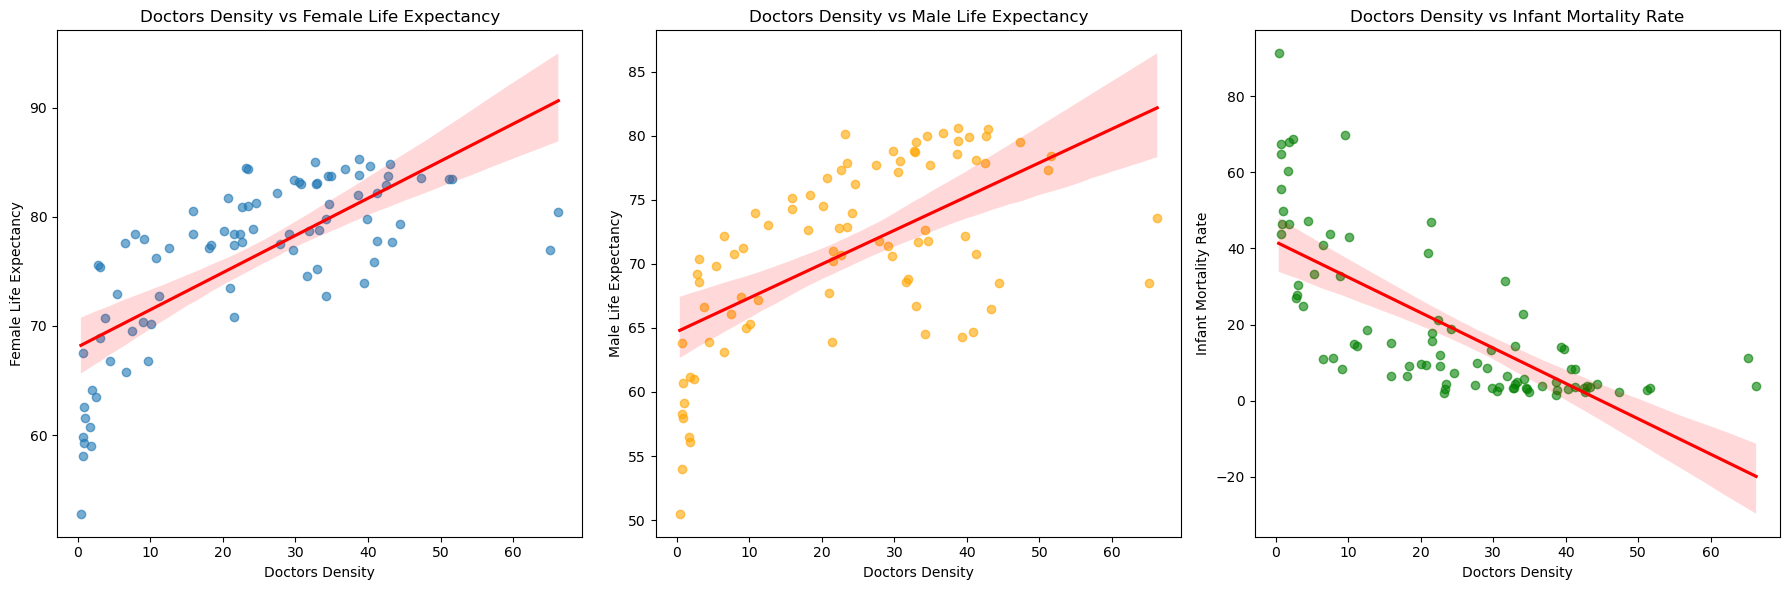

In [23]:
# Scatter plots with regression lines
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Medical doctors density vs Female Life Expectancy
sns.regplot(data=health_2017_final, x="Medical doctors density", y="Female life expectancy",
            ax=axes[0], scatter_kws={"alpha": 0.6}, line_kws={"color": "red"})
axes[0].set_title("Doctors Density vs Female Life Expectancy")
axes[0].set_xlabel("Doctors Density")
axes[0].set_ylabel("Female Life Expectancy")

# Medical doctors density vs Male Life Expectancy
sns.regplot(data=health_2017_final, x="Medical doctors density", y="Male life expectancy",
            ax=axes[1], color="orange", scatter_kws={"alpha": 0.6}, line_kws={"color": "red"})
axes[1].set_title("Doctors Density vs Male Life Expectancy")
axes[1].set_xlabel("Doctors Density")
axes[1].set_ylabel("Male Life Expectancy")

# Medical doctors density vs Infant Mortality Rate
sns.regplot(data=health_2017_final, x="Medical doctors density", y="Infant mortality rate",
            ax=axes[2], color="green", scatter_kws={"alpha": 0.6}, line_kws={"color": "red"})
axes[2].set_title("Doctors Density vs Infant Mortality Rate")
axes[2].set_xlabel("Doctors Density")
axes[2].set_ylabel("Infant Mortality Rate")

plt.tight_layout()
plt.show()


### Answer to Question 1

- Three indicators have been selected: Female Life Expectancy, Male Life Expectancy, and Infant Mortality Rate.

    | Correlation Coefficient| Female life expectancy   | Male life expectancy | Infant mortality rate |
    |----------------------------|-------|------------------|--------------------|
    | **Medical Doctors Density** | 0.723 | 0.607            | -0.718             |
    | **Nursing and Midwifery Density** | 0.679 | 0.666            | -0.664             |



    *Adebayo, T. S., Nwosu, L. C., Alhassan, G. N., Uzun, B., Özkan, O., & Awosusi, A. A. (2024). Effects of health expenditure, death rate, and infant mortality rate on life expectancy: A case study of the United States. *Energy & Environment*, 0958305X241281804.

The results from our analysis emphasize the significant impact of medical workforce density on improving life expectancy and reducing infant mortality rates. Beginning with **Medical Doctors Density**, the data reveals a strong positive correlation with both female and male life expectancy. Regions with a higher concentration of medical doctors experience longer life spans for both genders, reflecting the critical role of access to skilled healthcare providers in disease prevention, management, and overall health promotion. Additionally, these regions tend to have lower infant mortality rates, underscoring the importance of medical expertise in ensuring the survival and well-being of newborns.

Similarly, **Nursing and Midwifery Density** demonstrates a clear positive association with life expectancy for both females and males. The availability of trained nursing and midwifery professionals enhances the quality of care provided across all stages of life, particularly in maternal and neonatal health. This workforce is crucial in reducing infant mortality rates by delivering essential care during childbirth and the postnatal period. Higher densities of nursing and midwifery professionals translate to better outcomes for the most vulnerable populations.

In summary, our findings illustrate that greater densities of both medical doctors and nursing/midwifery professionals are strongly associated with improved health outcomes, including longer life expectancy and lower infant mortality rates. These results highlight the need for investments in expanding the healthcare workforce to strengthen health systems and improve population well-being.

## Question 2
## What is the relationship between the density of different medical staff and economic indicators across regions?

- Solutions: Our objective was to identify the **factors** associated with **a higher density of medical workforce**. To achieve this, we employed a correlation-based approach to quantify the relationships between selected variables and medical workforce density. Using Python's data visualization libraries, we standardized the variables of interest to ensure comparability and facilitate subsequent analyses. We then calculated the correlation coefficients between the target variable (medical workforce density) and the indicators, presenting the results in a heatmap for clarity. We identified indicators with strong positive correlations and further explored these relationships through scatter plots and trend lines to provide a detailed visual representation.

- Tools: **Python** (libraries `matplotlib` , `sklearn` and `seaborn`)

- The codes used are as follows with notes to provide references.

In [24]:
# Remove the specified columns: 'Country', 'Region_x', and 'Year_x'
health_2017_final_numeric = health_2017_final.drop(columns=["Country", "Region"])

# Normalize the remaining numeric variables
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(health_2017_final_numeric)

# Convert the scaled data back into a DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=health_2017_final_numeric.columns)

# Compute the correlation matrix for the scaled numeric data
correlation_matrix = scaled_df.corr()

# Display the correlation matrix
print(correlation_matrix)

                                    Nursing and midwifery density  \
Nursing and midwifery density                            1.000000   
Medical doctors density                                  0.645012   
Population density                                      -0.004180   
Urban population                                         0.606985   
GDP per capita                                           0.788792   
Infant mortality rate                                   -0.644343   
Health expenditure                                       0.551778   
Education government expenditure                         0.369596   
Tertiary education enrollment rate                       0.745726   
Unemployment (% of labour force)                        -0.088125   
Female life expectancy                                   0.679226   
Male life expectancy                                     0.665591   
Count Of Universities                                    0.284873   
Average Number Of Students        

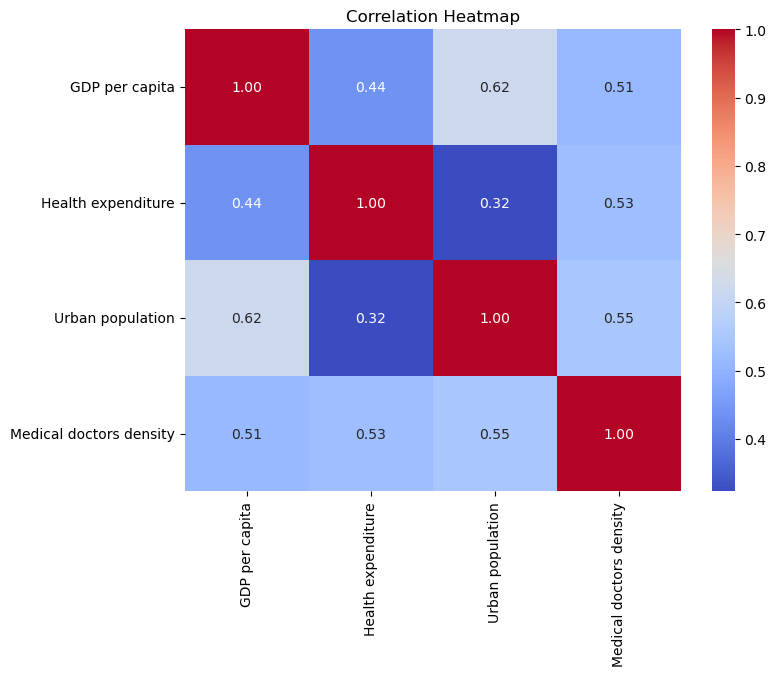

In [25]:
# Compute correlation matrix for doctors
correlation_doctor = health_2017_final_numeric[["GDP per capita", "Health expenditure", "Urban population", "Medical doctors density"]].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_doctor, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

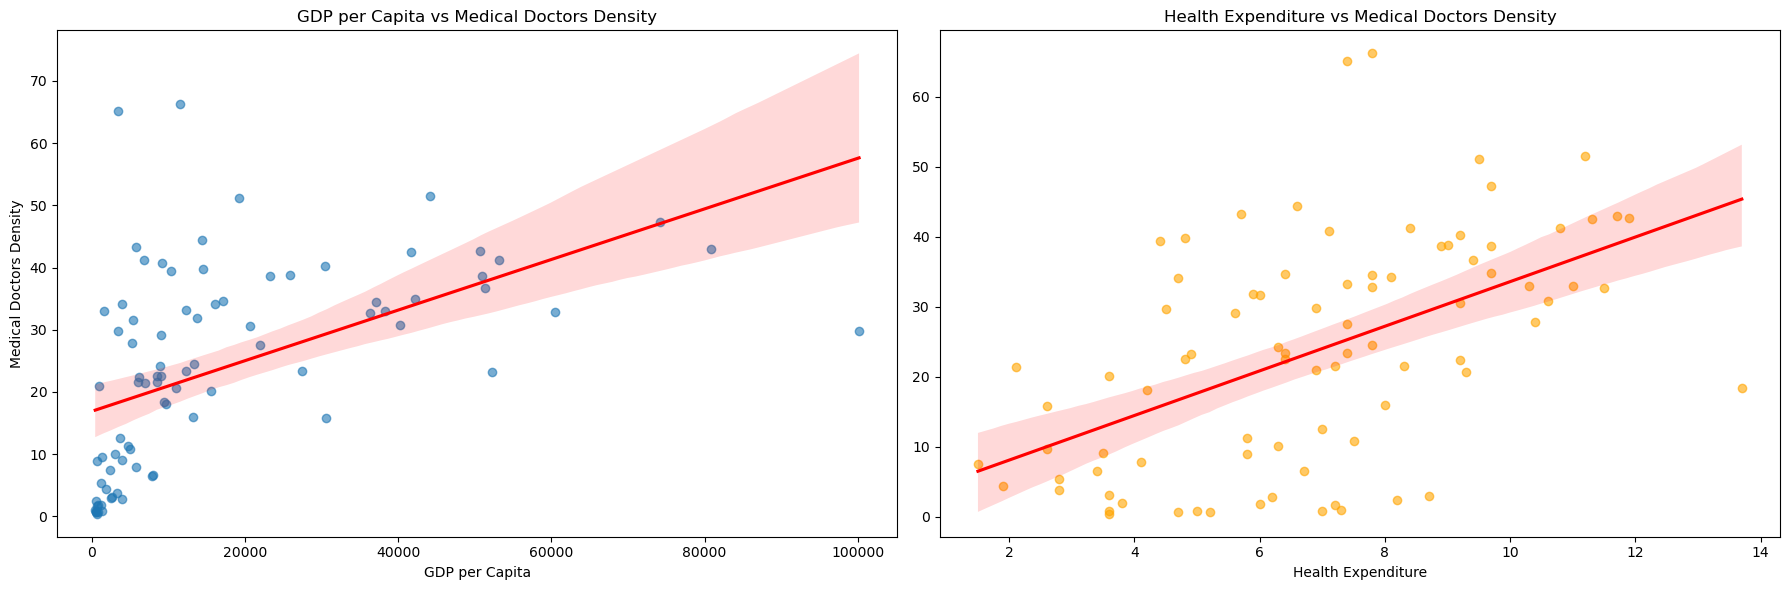

In [26]:
# Create subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# GDP per capita vs Medical doctors density with regression line
sns.regplot(data=health_2017_final, x="GDP per capita", y="Medical doctors density", ax=axes[0], scatter_kws={'alpha':0.6}, line_kws={"color": "red"})
axes[0].set_title("GDP per Capita vs Medical Doctors Density")
axes[0].set_xlabel("GDP per Capita")
axes[0].set_ylabel("Medical Doctors Density")

# Health expenditure vs Medical doctors density with regression line
sns.regplot(data=health_2017_final, x="Health expenditure", y="Medical doctors density", ax=axes[1], color="orange", scatter_kws={'alpha':0.6}, line_kws={"color": "red"})
axes[1].set_title("Health Expenditure vs Medical Doctors Density")
axes[1].set_xlabel("Health Expenditure")
axes[1].set_ylabel("")

# Adjust layout for better appearance
plt.tight_layout()
plt.show()



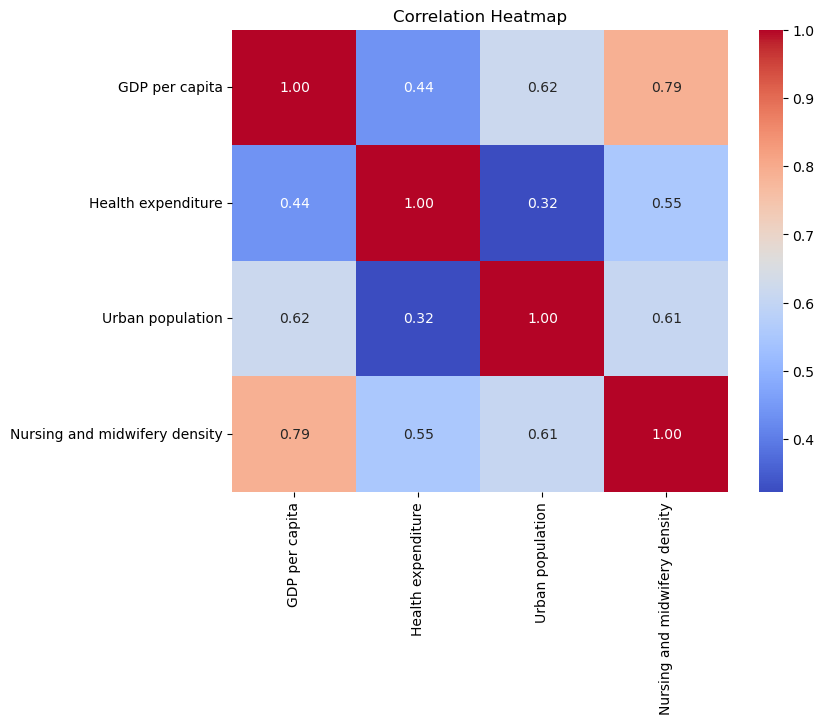

In [27]:
# Compute correlation matrix
correlation_nurse = health_2017_final[["GDP per capita", "Health expenditure", "Urban population", "Nursing and midwifery density"]].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_nurse, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

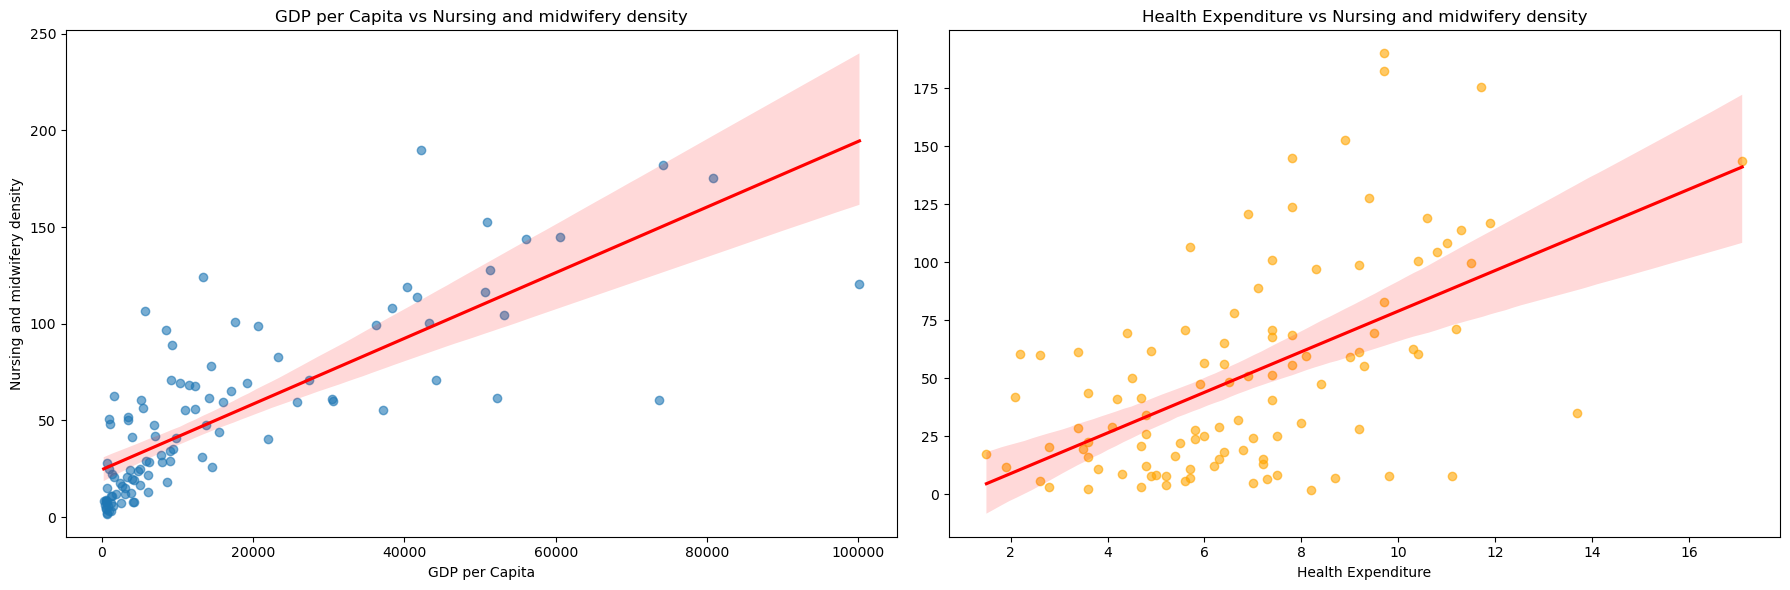

In [28]:
# Create subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# GDP per capita vs Medical doctors density with regression line
sns.regplot(data=health_2017_final, x="GDP per capita", y="Nursing and midwifery density", ax=axes[0], scatter_kws={'alpha':0.6}, line_kws={"color": "red"})
axes[0].set_title("GDP per Capita vs Nursing and midwifery density")
axes[0].set_xlabel("GDP per Capita")
axes[0].set_ylabel("Nursing and midwifery density")

# Health expenditure vs Medical doctors density with regression line
sns.regplot(data=health_2017_final, x="Health expenditure", y="Nursing and midwifery density", ax=axes[1], color="orange", scatter_kws={'alpha':0.6}, line_kws={"color": "red"})
axes[1].set_title("Health Expenditure vs Nursing and midwifery density")
axes[1].set_xlabel("Health Expenditure")
axes[1].set_ylabel("")


# Adjust layout for better appearance
plt.tight_layout()
plt.show()

In [29]:
health_2017_final.sort_values(by="Medical doctors density", ascending=False)

,Region,Country,Nursing and midwifery density,Medical doctors density,Population density,Urban population,GDP per capita,Infant mortality rate,Health expenditure,Education government expenditure,Tertiary education enrollment rate,Unemployment (% of labour force),Female life expectancy,Male life expectancy,Count Of Universities,Average Number Of Students
130,Americas,Cuba,77.306,81.229,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
117,Europe,Croatia,68.539,66.237,74.9,59.0,11479.4,3.9,7.8,4.6,69.30,11.7,80.4,73.6,NaN,NaN
94,Europe,Georgia,51.613,65.145,56.3,53.6,3491.4,11.2,7.4,2.0,43.50,11.4,77.0,68.5,NaN,NaN
69,Europe,Greece,35.914,61.016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,14650.0
128,Europe,Austria,71.079,51.567,106.0,66.0,44117.7,3.3,11.2,5.5,81.75,6.2,83.5,78.4,7.0,20584.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,Africa,Burundi,8.275,NaN,423.1,12.1,244.6,77.8,7.5,5.4,5.05,1.7,58.0,54.2,NaN,NaN
136,Africa,Democratic Republic of the Congo,8.667,NaN,35.9,42.5,486.2,73.2,4.3,2.2,6.65,3.6,59.5,56.7,NaN,NaN
140,Africa,Zambia,9.071,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
141,Americas,British Virgin Islands,93.688,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
health_2017_final.sort_values(by="Nursing and midwifery density", ascending=False)

,Region,Country,Nursing and midwifery density,Medical doctors density,Population density,Urban population,GDP per capita,Infant mortality rate,Health expenditure,Education government expenditure,Tertiary education enrollment rate,Unemployment (% of labour force),Female life expectancy,Male life expectancy,Count Of Universities,Average Number Of Students
38,Europe,Finland,189.984,34.892,18.2,84.2,42148.1,2.3,9.7,7.2,87.45,8.9,83.7,77.7,9.0,10798.0
37,Europe,Norway,182.183,47.345,14.5,80.5,74185.5,2.4,9.7,7.4,77.15,5.1,83.6,79.5,4.0,11623.0
32,Europe,Switzerland,175.442,42.978,214.5,73.9,80831.1,3.9,11.7,5.1,57.70,4.6,84.8,80.5,10.0,12551.0
27,Europe,Iceland,152.881,38.708,3.3,94.1,50936.0,1.6,8.9,7.8,81.65,3.6,83.8,80.6,1.0,13960.0
23,Europe,Ireland,144.848,32.817,69.1,63.2,60513.6,3.4,7.8,5.3,83.85,7.6,83.0,78.7,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,Africa,Togo,4.118,0.742,143.4,40.0,559.4,55.7,5.2,5.2,10.65,6.8,59.8,58.3,NaN,NaN
63,Africa,Senegal,3.181,0.703,82.3,43.7,901.1,43.9,4.7,7.4,10.35,9.3,67.5,63.8,NaN,NaN
62,South-East Asia,Bangladesh,3.122,5.362,1265.0,34.3,1207.9,33.3,2.8,1.9,13.40,4,72.9,69.8,1.0,62716.0
41,Africa,Chad,2.311,0.432,11.8,22.5,713.0,91.2,3.6,2.8,3.40,5.8,52.8,50.5,NaN,NaN


### Answer to Question 2:

- #### Three major factors: GDP per capita, urban population and health expenditure

    | Correlation Coefficient                  | GDP   | Urban Population | Health Expenditure |
    |----------------------------|-------|------------------|--------------------|
    | **Medical Doctors Density** | 0.514 | 0.545            | 0.526             |
    | **Nursing and Midwifery Density** | 0.789 | 0.607            | 0.552             |




The analysis of factors associated with a higher density of medical doctors, nursing and midwifery across regions shows some key patterns.  **GDP per Capita** is strongly positively correlated with both medical doctors density and nursing and midwifery density. This indicates that wealthier nations, with higher economic resources, tend to have greater investments in healthcare personnel. Higher GDP could lead to better education (which we would specifically discuss in the following question), training, and retention of medical staff, increasing their density.

**Health Expenditure** shows a similarly positive trend with both nursing and medical doctors density. Countries that allocate more funds to healthcare can afford to employ and sustain a larger workforce of healthcare professionals.

In summary, a combination of economic strength, healthcare and investment significantly influences the density of medical and nursing personnel across regions. These findings highlight the importance of targeted investments and policies to enhance healthcare capacity, particularly in and economically disadvantaged regions.

## Question 3
## How does tertiary education differ throughout different countries and does it relate to the density of medical staff?

### Answer to Question 3:

Countries with higher tertiary enrollment tend to have greater densities of medical staff, particularly in nursing and midwifery roles. This highlights the critical role of tertiary education in strengthening healthcare systems. Addtionally, the variation in enrollment rates underscores the unequal access to higher education globally, impacting countries' ability to train sufficient medical staff.


| Coefficient Type           | Slope (Rate of Change) | Intercept |
|----------------------------|------------------------|-----------------------------|
| Medical Doctors Density    | 0.3751                | 6.8832                      |
| Nursing and Midwifery Density | 1.0989             | 8.3743                      |

The anaysis revealed that For every 1% increase in tertiary education enrollment, nursing and midwifery density increases by around 1.10 per 10,000 population and for every 1% increase in tertiary education enrollment, the medical doctor density increases by  0.375 per 10,000 population.

Overall:

* There is a relationship between tertiary education enrollment rates and total medical staff density. Countries with better access to higher education tend to have more robust healthcare workforces.

* Americas and Western Pacific regions has a higher average student populations, indicating larger educational systems that may better support training for medical staff. Africa and Eastern Mediterranean regions reflect smaller student populations and potentially limited capacity to train sufficient healthcare workers.

* Nursing and midwifery density is higher than medical doctor density, indicating a more substantial reliance on nursing staff in most countries.

Tools: **Python** (libraries `pandas`. `numpy` and `matplotlib`)


In [40]:
Educationdf = health_2017_final[["Region", "Country", "Medical doctors density", "Nursing and midwifery density","Education government expenditure", "Tertiary education enrollment rate", "Count Of Universities", "Average Number Of Students"]]

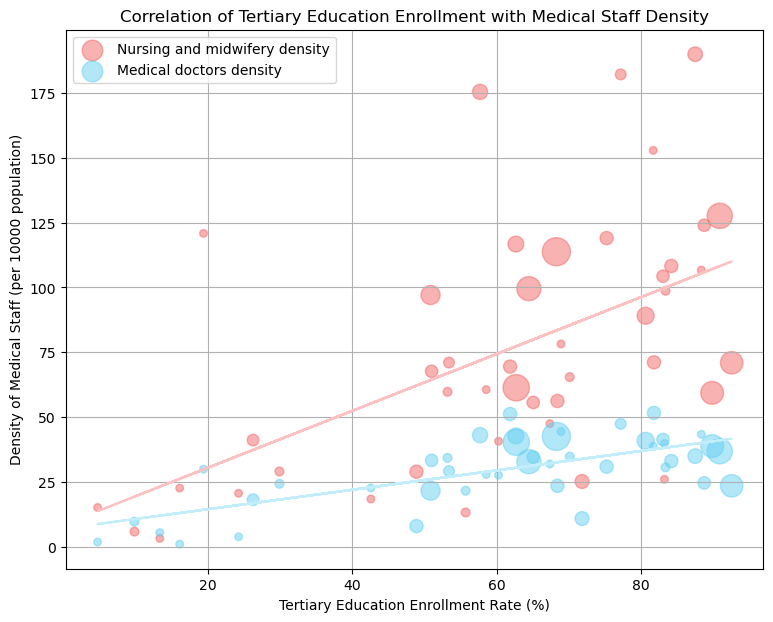

In [ ]:
import numpy as np

plt.figure(figsize=(9, 7))

df_cleaned_for_plot = Educationdf.dropna(
    subset=["Tertiary education enrollment rate", "Nursing and midwifery density", "Medical doctors density", "Count Of Universities"]
)

# Scatter plot for nursing and midwifery density
plt.scatter(
    df_cleaned_for_plot["Tertiary education enrollment rate"],
    df_cleaned_for_plot["Nursing and midwifery density"],
    s=df_cleaned_for_plot["Count Of Universities"] * 10 + 20,  
    alpha=0.5,
    label="Nursing and midwifery density",
    color="#f26666"
)

# Scatter plot for medical doctors density
plt.scatter(
    df_cleaned_for_plot["Tertiary education enrollment rate"],
    df_cleaned_for_plot["Medical doctors density"],
    s=df_cleaned_for_plot["Count Of Universities"] * 10 + 20,  
    alpha=0.5,
    label="Medical doctors density",
    color="#66d0f2"
)

# Trend line for nursing and midwifery density
nursing_fit = np.polyfit(
    df_cleaned_for_plot["Tertiary education enrollment rate"],
    df_cleaned_for_plot["Nursing and midwifery density"],
    1
)
nursing_trend = np.poly1d(nursing_fit)
plt.plot(
    df_cleaned_for_plot["Tertiary education enrollment rate"],
    nursing_trend(df_cleaned_for_plot["Tertiary education enrollment rate"]),
    color="#fcc2c2"
)

# Trend line for medical doctors density
doctors_fit = np.polyfit(
    df_cleaned_for_plot["Tertiary education enrollment rate"],
    df_cleaned_for_plot["Medical doctors density"],
    1
)
doctors_trend = np.poly1d(doctors_fit)
plt.plot(
    df_cleaned_for_plot["Tertiary education enrollment rate"],
    doctors_trend(df_cleaned_for_plot["Tertiary education enrollment rate"]),
    color="#c2eefc"
)


plt.title("Correlation of Tertiary Education Enrollment with Medical Staff Density")
plt.xlabel("Tertiary Education Enrollment Rate (%)")
plt.ylabel("Density of Medical Staff (per 10,000 population)")
plt.legend()
plt.grid()
plt.show()


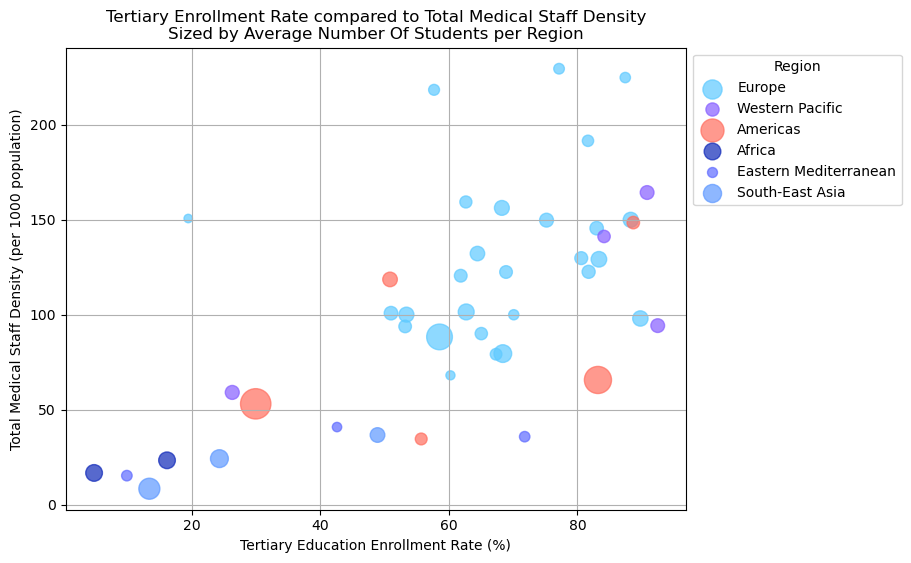

In [ ]:
plt.figure(figsize=(8, 6))

# Total medical staff density
Educationdf.loc["Total medical staff density"] = (Educationdf["Medical doctors density"] + Educationdf["Nursing and midwifery density"])

regioncolors = {
    "Africa": "#1029b9",
    "Americas": "#ff6e5f",
    "Eastern Mediterranean": "#5f6bff",
    "Europe": "#5fcaff",
    "South-East Asia": "#5f99ff",
    "Western Pacific": "#865fff",
}


for region in df_cleaned_for_plot["Region"].unique():
    region_data = df_cleaned_for_plot[df_cleaned_for_plot["Region"] == region]
    plt.scatter(
        region_data["Tertiary education enrollment rate"],
        region_data["Total medical staff density"],
        s=region_data["Average Number Of Students"] / 300 + 20, 
        alpha=0.7,
        label=region,
        color=regioncolors.get(region, "gray") 
    )

plt.title("Tertiary Enrollment Rate compared to Total Medical Staff Density\nSized by Average Number Of Students per Region")
plt.xlabel("Tertiary Education Enrollment Rate (%)")
plt.ylabel("Total Medical Staff Density (per 10,000 population)")
plt.legend(title="Region", loc="upper left", bbox_to_anchor=(1, 1))
plt.grid(True)
plt.show()


# Question 4: Web Scraping
## How to track Health and SDG Progress Through Key Indicators

- Solution: The script utilizes Selenium for web scraping by automating the Chrome browser to extract data from the Worldometers website. Selenium ensures smooth navigation, even in headless mode, for fast and efficient data collection. Pandas is used for data manipulation and analysis, storing the scraped data in a structured format. This data is converted into a pandas DataFrame for easy handling and further analysis. ChromeDriverManager is employed to automatically manage the correct version of the Chrome WebDriver, ensuring compatibility with the system’s Chrome browser and enabling seamless interaction with Selenium.
- Tools:  **Selenium** ,**webdriver_manager**,**Pandas**
- The codes used are as follows with notes to provide references.


In [89]:
# Install the 'selenium' package
!pip install selenium
# Explanation:
# 'selenium' is a Python package that allows for browser automation. It enables you to open a browser window, interact with web pages, and scrape content programmatically. 
# Selenium is commonly used for tasks like web scraping, automated testing, and interacting with dynamic web pages.

# Install the 'webdriver_manager' package
!pip install webdriver_manager
# Explanation:
# 'webdriver_manager' is a Python package that simplifies the management of web drivers (e.g., ChromeDriver, GeckoDriver). 
# Normally, to use Selenium with a web browser (like Chrome), you need to download the corresponding driver (e.g., ChromeDriver for Chrome).
# This package automatically handles the installation and management of the appropriate driver for your browser, ensuring compatibility without manual intervention.


In [90]:
# Import necessary libraries
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
import pandas as pd
import time
from datetime import datetime

# Set up Chrome options for headless browsing (no GUI)
chrome_options = Options()
chrome_options.add_argument("--headless")  # Runs Chrome in headless mode (without GUI)
chrome_options.add_argument("--no-sandbox")  # Disables the sandbox security feature (useful in some environments)
chrome_options.add_argument("--disable-dev-shm-usage")  # Prevents issues related to memory allocation in Docker

# Set up the service to manage the ChromeDriver using webdriver_manager
service = Service(ChromeDriverManager().install())

# Initialize the WebDriver with the configured service and options
driver = webdriver.Chrome(service=service, options=chrome_options)

# Target URL
url = "https://www.worldometers.info/"

# Open the webpage
driver.get(url)

# Wait for 3 seconds to allow the page to load completely
time.sleep(3)

# Initialize an empty list to store the scraped data
data = []

# Get the current timestamp (when the data is collected)
current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# -----------------------------------------
# Health/Death section: Extract health statistics
# -----------------------------------------

# Locate the "Health" section by finding the element that contains the text 'Health'
HealthSection = driver.find_element("xpath", "//div[contains(@class, 'counter-title') and text()='Health']")

# Find all the counter groups (the specific health statistics) within the Health section
Health = HealthSection.find_elements("xpath", "./following-sibling::div[contains(@class, 'counter-group')]")

# Loop through each health-related counter and extract the data
for counter in Health:
    # Extract the indicator (e.g., "Deaths today")
    indicator = counter.find_element("xpath", ".//span[contains(@class, 'counter-item')]").text
    # Extract the number (e.g., the value of deaths)
    number = counter.find_element("xpath", ".//span[contains(@class, 'rts-counter')]").text
    # Append the extracted data along with the timestamp to the list
    data.append({"Indicator": indicator, "Number": number, "Timestamp": current_time})

# -------------------------------------------
# Expenditure section: Extract government data
# -------------------------------------------

# Locate the "Government & Economics" section by finding the element with the title 'Government & Economics'
ExpenditureSection = driver.find_element("xpath", "//div[contains(@class, 'counter-title') and text()='Government & Economics']")

# Find all the counter groups (the specific expenditure statistics) within the Expenditure section
Expenditure = ExpenditureSection.find_elements("xpath", "./following-sibling::div[contains(@class, 'counter-group')]")

# Loop through each expenditure counter and extract relevant data
for counter in Expenditure:
    # Extract the indicator (e.g., "Public Healthcare expenditure")
    indicator = counter.find_element("xpath", ".//span[contains(@class, 'counter-item')]").text
    # Check if the indicator matches "Public Healthcare expenditure" or "Public Education expenditure"
    if "Public Healthcare expenditure" in indicator or "Public Education expenditure" in indicator:
        # Extract the number (e.g., the value of the expenditure)
        number = counter.find_element("xpath", ".//span[contains(@class, 'rts-counter')]").text
        # Append the extracted data along with the timestamp to the list
        data.append({"Indicator": indicator, "Number": number, "Timestamp": current_time})

# -----------------------------------------------
# Convert the collected data into a pandas DataFrame
# -----------------------------------------------

# Create a DataFrame to store the extracted data in a tabular format
currentHealthdf = pd.DataFrame(data)

# Close the browser window after the data is collected
driver.quit()

In [91]:
# Save the DataFrame to a CSV file
currentHealthdf.to_csv("currentHealthdf.csv")

### Answer to Question 4

In [92]:
currentHealthdf

,Indicator,Number,Timestamp
0,Communicable disease deaths this year,"11,728,456",2024-11-25 19:13:05
1,Seasonal flu deaths this year,"461,409",2024-11-25 19:13:05
2,Deaths of children under 5 this year,"6,867,244",2024-11-25 19:13:05
3,Abortions this year,"40,694,305",2024-11-25 19:13:05
4,Deaths of mothers during birth this year,"279,249",2024-11-25 19:13:05
5,HIV/AIDS infected people,"45,965,431",2024-11-25 19:13:05
6,Deaths caused by HIV/AIDS this year,"1,518,772",2024-11-25 19:13:05
7,Deaths caused by cancer this year,"7,420,043",2024-11-25 19:13:05
8,Deaths caused by malaria this year,"356,270",2024-11-25 19:13:05
9,Cigarettes smoked today,"12,143,852,273",2024-11-25 19:13:05


Tracking health and Sustainable Development Goal (SDG) progress through key indicators is essential for ensuring the successful achievement of global health and development targets. Web scraping enables the extraction of real-time data on critical health and SDG indicators such as mortality rates, vaccination coverage, healthcare spending, and environmental factors. By gathering up-to-date data from reliable platforms, stakeholders can stay informed about the progress of SDG targets, detect early signs of health risks, and adjust strategies to address gaps.